<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 19 - Ejemplo 2 - Métodos de ensamble
        </td>
    </tr>
    <tr>
 

</table>

In [1]:
import numpy as np
import pandas as pd
import array
import matplotlib.pyplot as plt
import seaborn as sns
import math
from plotnine import *
from array import*
import scipy.stats as stats
from sklearn.linear_model import LinearRegression 
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import os, sys

Se cuenta con un conjunto de datos sobre la calidad del agua compuesto por 3276 registros y 10 variables. El objetivo es desarrollar un modelo de aprendizaje automático supervisado capaz de clasificar si una muestra de agua es potable o no potable a partir de diferentes características fisicoquímicas.

La variable objetivo es Potability, la cual indica si el agua es apta para el consumo humano o no. Por lo tanto, el problema corresponde a una tarea de clasificación binaria.

Las variables disponibles en el conjunto de datos son:

| Variable | Descripción |
|---|---|
| ph | Nivel de acidez o alcalinidad del agua |
| Hardness | Dureza del agua, relacionada con la concentración de minerales |
| Solids | Cantidad de sólidos disueltos en el agua |
| Chloramines | Concentración de cloraminas presentes en el agua |
| Sulfate | Concentración de sulfatos |
| Conductivity | Capacidad del agua para conducir electricidad |
| Organic_carbon | Cantidad de carbono orgánico presente en el agua |
| Trihalomethanes | Concentración de trihalometanos |
| Turbidity | Nivel de turbidez o falta de transparencia del agua |
| Potability | Variable objetivo que indica si el agua es potable o no |

El conjunto de datos presenta valores faltantes en algunas variables, específicamente en ph, Sulfate y Trihalomethanes, por lo que será necesario realizar un proceso de limpieza o imputación antes de entrenar los modelos.

El propósito del análisis es entrenar y evaluar modelos de clasificación que permitan predecir la potabilidad del agua. Para ello, se pueden utilizar algoritmos como regresión logística, árbol de decisión, random forest, bagging, pasting o gradient boosting.

El desarrollo del problema incluye las siguientes etapas:

1. Explorar inicialmente el conjunto de datos.
2. Identificar las variables predictoras y la variable objetivo.
3. Revisar y tratar los valores faltantes.
4. Dividir los datos en conjunto de entrenamiento y conjunto de prueba.
5. Entrenar diferentes modelos de clasificación.
6. Evaluar los modelos utilizando métricas como accuracy, precisión, recall, F1-score y matriz de confusión.
7. Comparar los resultados obtenidos.
8. Seleccionar el modelo con mejor desempeño predictivo.

In [2]:
datos = pd.read_csv("water_potability.csv")

In [3]:
datos

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [4]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [5]:
predictoras = datos.drop("Potability", axis=1)
respuesta = datos["Potability"]

In [6]:
predictoras

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075
...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658


<Figure size 640x480 with 0 Axes>

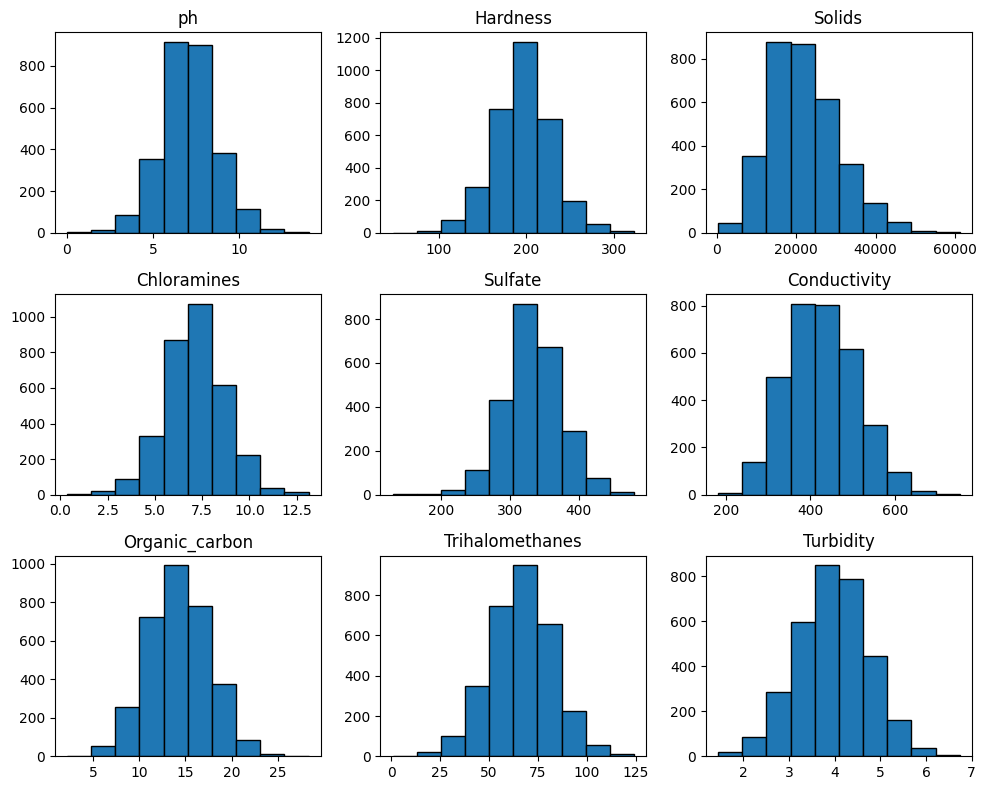

In [7]:
plt.figure()
predictoras.hist(figsize=(10,8),bins=10, edgecolor="black", grid=False)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.impute import SimpleImputer

imputador = SimpleImputer(strategy="median")
imputador.fit(predictoras)
predictoras_i = pd.DataFrame(imputador.transform(predictoras), columns=predictoras.columns)

In [9]:
predictoras_i

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075
...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821
3272,7.808856,193.553212,17329.802160,8.061362,333.073546,392.449580,19.903225,66.622485,2.798243
3273,9.419510,175.762646,33155.578218,7.350233,333.073546,432.044783,11.039070,69.845400,3.298875
3274,5.126763,230.603758,11983.869376,6.303357,333.073546,402.883113,11.168946,77.488213,4.708658


In [10]:
#Particionar los datos en entrenamiento y validación
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(predictoras_i, respuesta, test_size=0.20, random_state=2026)

In [11]:
from sklearn.tree import DecisionTreeClassifier

#Crear el objeto de clase árbol con los parámetros por defecto
tree_clf = DecisionTreeClassifier(max_depth=3,random_state = 2026)
#Ajustar el arbol
tree_clf.fit(X_train, y_train);

[Text(0.5, 0.875, 'x[4] <= 258.97\ngini = 0.475\nsamples = 2620\nvalue = [1602.0, 1018.0]'),
 Text(0.25, 0.625, 'x[2] <= 15309.842\ngini = 0.375\nsamples = 68\nvalue = [17, 51]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[0] <= 7.947\ngini = 0.426\nsamples = 13\nvalue = [9, 4]'),
 Text(0.0625, 0.125, 'gini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.1875, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.375, 0.375, 'x[7] <= 60.081\ngini = 0.249\nsamples = 55\nvalue = [8, 47]'),
 Text(0.3125, 0.125, 'gini = 0.469\nsamples = 16\nvalue = [6, 10]'),
 Text(0.4375, 0.125, 'gini = 0.097\nsamples = 39\nvalue = [2, 37]'),
 Text(0.75, 0.625, 'x[4] <= 387.796\ngini = 0.471\nsamples = 2552\nvalue = [1585, 967]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[0] <= 4.636\ngini = 0.465\nsamples = 2363\nvalue = [1493, 870]'),
 Text(0.5625, 0.125, 'gini = 0.307\nsamples = 116\nvalue = [94, 22]'),
 Text(0.6875, 0.125, 'gini = 0.47\nsamples = 2247\nvalue = [1399, 848]'),

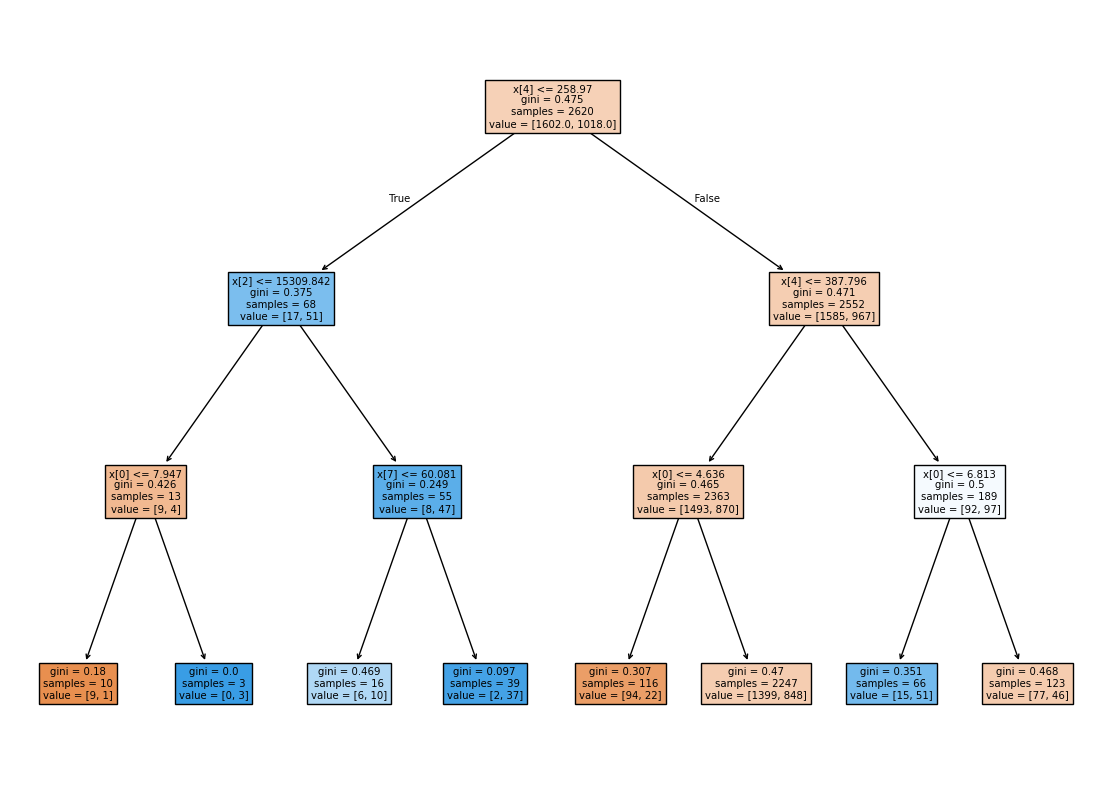

In [12]:
from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf,filled=True)

In [13]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_a = tree_clf.predict(X_test)
accuracy_a = accuracy_score(y_test, y_pred_a)
print("El accuracy score que se tiene es %s" %accuracy_a)

El accuracy score que se tiene es 0.6341463414634146


Text(50.722222222222214, 0.5, 'Real')

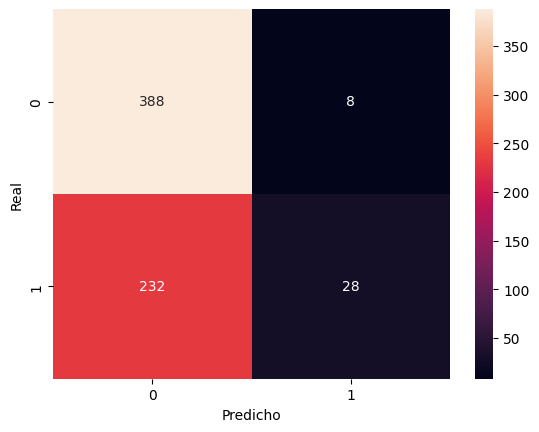

In [14]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_a)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_a = precision_score(y_test, y_pred_a)
recall_a = recall_score(y_test, y_pred_a)
f1_a = f1_score(y_test, y_pred_a)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_a, recall_a,f1_a]})
metricas

,Métricas,Valores
0,Precisión,0.777778
1,Recall,0.107692
2,F1,0.189189


Se entrenó un modelo de árbol de decisión con una profundidad máxima de 3, obteniendo un accuracy score de 0.6341463414634146, lo que indica que clasificó correctamente aproximadamente el 63.41% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.728676, un recall de 0.678767 y un F1-score de 0.702837. Estos resultados muestran que el modelo tiene una capacidad moderada para clasificar si una muestra de agua es potable o no. La precisión indica que, cuando el modelo predice una clase positiva, suele acertar en una proporción aceptable; mientras que el recall muestra que logra identificar aproximadamente el 67.88% de los casos positivos reales. En general, el árbol de decisión con max_depth=3 presenta un desempeño aceptable, aunque todavía puede mejorarse mediante el ajuste de hiperparámetros o la comparación con otros modelos de clasificación.

In [16]:
from sklearn.tree import DecisionTreeClassifier

#Crear el objeto de clase árbol con los parámetros por defecto
tree_clf_b = DecisionTreeClassifier(min_samples_leaf=200, random_state = 2026)
#Ajustar el arbol
tree_clf_b.fit(X_train, y_train);

[Text(0.375, 0.9444444444444444, 'x[4] <= 283.922\ngini = 0.475\nsamples = 2620\nvalue = [1602.0, 1018.0]'),
 Text(0.25, 0.8333333333333334, 'gini = 0.486\nsamples = 209\nvalue = [87.0, 122.0]'),
 Text(0.3125, 0.8888888888888888, 'True  '),
 Text(0.5, 0.8333333333333334, 'x[4] <= 363.505\ngini = 0.467\nsamples = 2411\nvalue = [1515.0, 896.0]'),
 Text(0.4375, 0.8888888888888888, '  False'),
 Text(0.25, 0.7222222222222222, 'x[0] <= 5.609\ngini = 0.456\nsamples = 1948\nvalue = [1264, 684]'),
 Text(0.125, 0.6111111111111112, 'gini = 0.372\nsamples = 267\nvalue = [201, 66]'),
 Text(0.375, 0.6111111111111112, 'x[1] <= 164.344\ngini = 0.465\nsamples = 1681\nvalue = [1063, 618]'),
 Text(0.25, 0.5, 'gini = 0.5\nsamples = 200\nvalue = [98, 102]'),
 Text(0.5, 0.5, 'x[6] <= 12.602\ngini = 0.454\nsamples = 1481\nvalue = [965, 516]'),
 Text(0.25, 0.3888888888888889, 'x[2] <= 20021.766\ngini = 0.485\nsamples = 447\nvalue = [262, 185]'),
 Text(0.125, 0.2777777777777778, 'gini = 0.448\nsamples = 221\nv

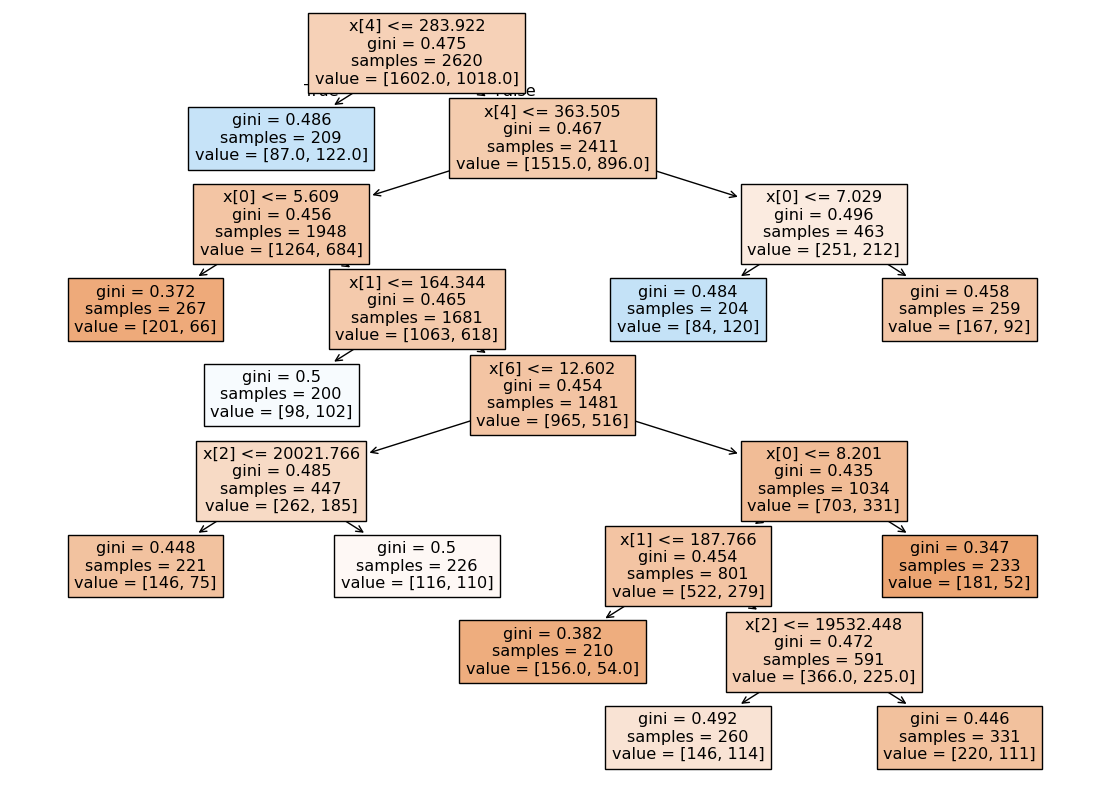

In [17]:
from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf_b,filled=True)

In [18]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_b = tree_clf_b.predict(X_test)
accuracy_b = accuracy_score(y_test, y_pred_b)
print("El accuracy score que se tiene es %s" %accuracy_b)

El accuracy score que se tiene es 0.6341463414634146


Text(50.722222222222214, 0.5, 'Real')

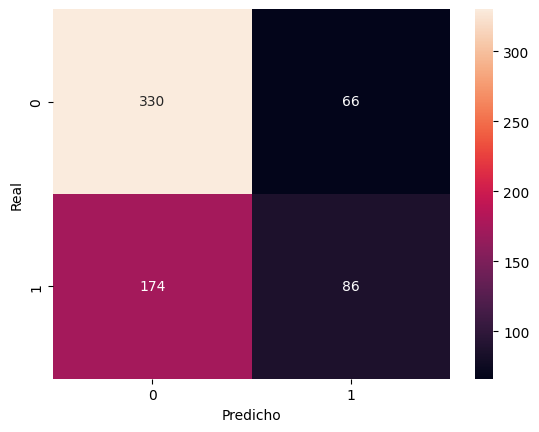

In [19]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_b = precision_score(y_test, y_pred_b)
recall_b = recall_score(y_test, y_pred_b)
f1_b = f1_score(y_test, y_pred_b)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_b, recall_b,f1_b]})
metricas

,Métricas,Valores
0,Precisión,0.565789
1,Recall,0.330769
2,F1,0.417476


Se entrenó otro modelo de árbol de decisión utilizando min_samples_leaf=200, obteniendo un accuracy score de 0.6341463414634146, lo que indica que clasificó correctamente aproximadamente el 63.41% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.565789, un recall de 0.330769 y un F1-score de 0.417476. Aunque el accuracy es igual al obtenido por el árbol con max_depth=3, las demás métricas muestran un rendimiento inferior, especialmente en recall y F1-score. Esto indica que el modelo tiene menor capacidad para identificar correctamente los casos positivos, es decir, las muestras de agua potable. En general, el uso de min_samples_leaf=200 hace que el árbol sea más restrictivo, lo que puede reducir su capacidad para detectar adecuadamente las muestras potables.

In [21]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=300, max_samples=75, bootstrap=True, random_state=2026)
bag_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",300
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",75
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",2026
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [22]:
#Obtener el accuracy_score
y_pred_bag = bag_clf.predict(X_test)
accuracy_bag = accuracy_score(y_test, y_pred_bag)
print("El accuracy score que se tiene es %s" %accuracy_bag)

El accuracy score que se tiene es 0.635670731707317


Text(50.722222222222214, 0.5, 'Real')

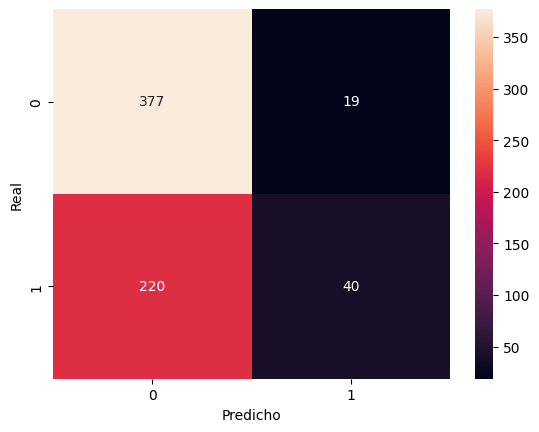

In [23]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_bag)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_bag = precision_score(y_test, y_pred_bag)
recall_bag = recall_score(y_test, y_pred_bag)
f1_bag = f1_score(y_test, y_pred_bag)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_bag, recall_bag,f1_bag]})
metricas

,Métricas,Valores
0,Precisión,0.677966
1,Recall,0.153846
2,F1,0.250784


Se entrenó un modelo de bagging, obteniendo un accuracy score de 0.635670731707317, lo que indica que clasificó correctamente aproximadamente el 63.57% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.677966, un recall de 0.153846 y un F1-score de 0.250784. Aunque el accuracy es ligeramente superior al de los árboles de decisión anteriores, el recall es bastante bajo, lo que significa que el modelo identifica correctamente una proporción muy pequeña de los casos positivos, es decir, de las muestras de agua potable. La precisión muestra que, cuando el modelo predice una muestra como potable, suele acertar en una proporción aceptable; sin embargo, al detectar pocos casos positivos, su desempeño general para esta clase es limitado. En general, el modelo bagging no representa una mejora importante, ya que su bajo recall y F1-score indican una baja capacidad para reconocer correctamente las muestras potables.

In [24]:
#Modelo usando Pasting

clf_pas = BaggingClassifier(DecisionTreeClassifier(), n_estimators=300, max_samples=75, bootstrap=False, random_state=2026)
clf_pas.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",300
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",75
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",False
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",2026
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [26]:
#Obtener el accuracy_score
y_pred_pas = clf_pas.predict(X_test)
accuracy_pas = accuracy_score(y_test, y_pred_pas)
print("El accuracy score que se tiene es %s" %accuracy_pas)

El accuracy score que se tiene es 0.6219512195121951


Text(50.722222222222214, 0.5, 'Real')

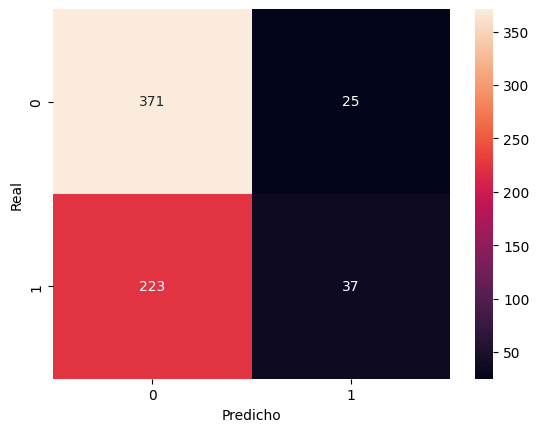

In [27]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_pas)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [28]:

#Obtener la presición, recall y f1
precision_pas = precision_score(y_test, y_pred_pas)
recall_pas = recall_score(y_test, y_pred_pas)
f1_pas = f1_score(y_test, y_pred_pas)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_pas, recall_pas,f1_pas]})
metricas

,Métricas,Valores
0,Precisión,0.596774
1,Recall,0.142308
2,F1,0.229814


Se entrenó un modelo de pasting, obteniendo un accuracy score de 0.6219512195121951, lo que indica que clasificó correctamente aproximadamente el 62.20% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.596774, un recall de 0.142308 y un F1-score de 0.229814. Estos resultados muestran que el modelo tiene una capacidad limitada para identificar correctamente las muestras de agua potable, ya que el recall es bastante bajo y solo detecta una pequeña proporción de los casos positivos reales. Aunque la precisión indica que algunas predicciones positivas son correctas, el bajo F1-score refleja un desequilibrio importante entre precisión y recall. En comparación con bagging, el modelo de pasting presenta un desempeño ligeramente menor tanto en accuracy como en precisión, recall y F1-score, por lo que no representa una mejora para este problema de clasificación.

In [29]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=300, max_leaf_nodes=15, random_state=2026)
rnd_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",15
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [30]:
#Obtener el accuracy_score
y_pred_rf = rnd_clf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("El accuracy score que se tiene es %s" %accuracy_rf)

El accuracy score que se tiene es 0.6387195121951219


Text(50.722222222222214, 0.5, 'Real')

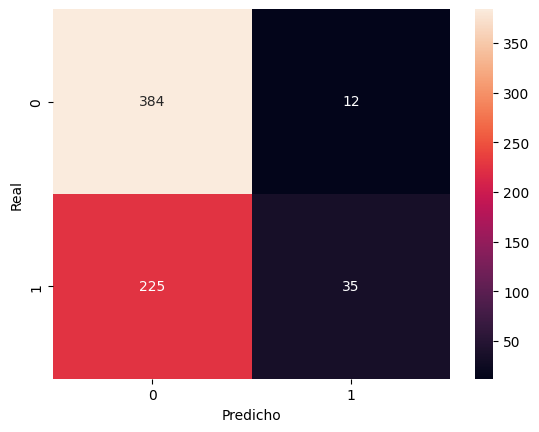

In [31]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_rf, recall_rf,f1_rf]})
metricas

,Métricas,Valores
0,Precisión,0.744681
1,Recall,0.134615
2,F1,0.228013


Se entrenó un modelo de random forest, obteniendo un accuracy score de 0.6448170731707317, lo que indica que clasificó correctamente aproximadamente el 64.48% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.787234, un recall de 0.142308 y un F1-score de 0.241042. Estos resultados muestran que el modelo tiene una precisión alta al clasificar muestras como potables, es decir, cuando predice que una muestra pertenece a la clase positiva, suele acertar en una proporción considerable. Sin embargo, el recall es muy bajo, lo que indica que el modelo solo identifica una pequeña parte de las muestras potables reales y deja muchas sin detectar. Aunque random forest obtiene el accuracy más alto hasta el momento, su bajo recall y F1-score muestran que su desempeño para reconocer correctamente la clase positiva sigue siendo limitado.

(-1.0, 9.0)

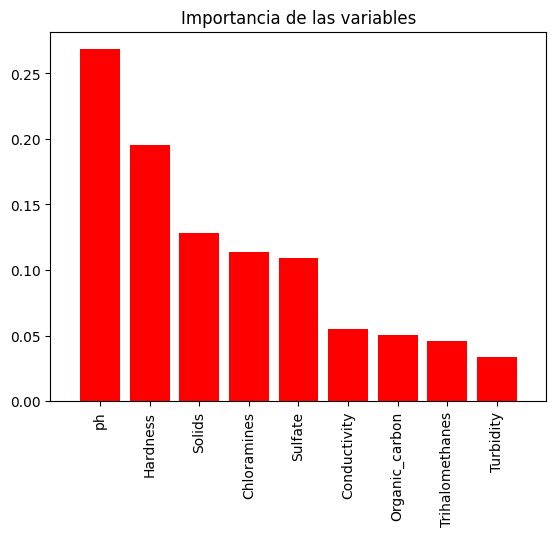

In [33]:
importancias = rnd_clf.feature_importances_
indices = np.argsort(importancias)[::-1]

plt.title("Importancia de las variables")
plt.bar(range(X_train.shape[1]), importancias[indices], color="r", align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns, rotation=90)
plt.xlim([-1, X_train.shape[1]])

(-1.0, 9.0)

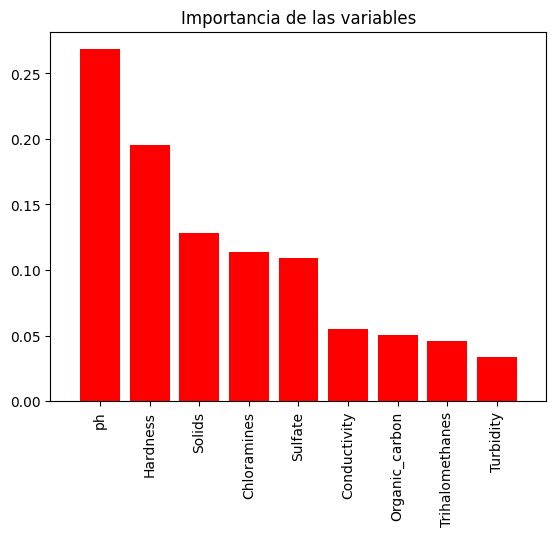

In [38]:
importancias = rnd_clf.feature_importances_

importancias_df = pd.DataFrame({"Variables": predictoras.columns,
                                "Importancias": rnd_clf.feature_importances_})
indices = np.argsort(importancias)[::-1]

plt.title("Importancia de las variables")
plt.bar(range(X_train.shape[1]), importancias[indices], color="r", align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns, rotation=90)
plt.xlim([-1, X_train.shape[1]])

In [34]:
#Cargar librerias
from sklearn.ensemble import GradientBoostingClassifier

# crear objeto de la clase BaggingClassifier
gb_clf = GradientBoostingClassifier(n_estimators = 300,random_state = 2026)

gb_clf.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [35]:
#Obtener el accuracy_score
y_pred_gb= gb_clf.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("El accuracy score que se tiene es %s" %accuracy_gb)

El accuracy score que se tiene es 0.635670731707317


Text(50.722222222222214, 0.5, 'Real')

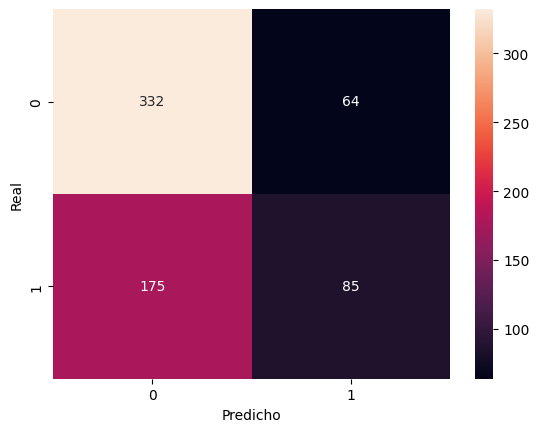

In [36]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_gb, recall_gb,f1_gb]})
metricas

,Métricas,Valores
0,Precisión,0.570470
1,Recall,0.326923
2,F1,0.415648


Se entrenó un modelo de gradient boosting, obteniendo un accuracy score de 0.635670731707317, lo que indica que clasificó correctamente aproximadamente el 63.57% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.570470, un recall de 0.326923 y un F1-score de 0.415648. Estos resultados muestran que el modelo tiene un desempeño moderado, aunque todavía limitado para identificar correctamente las muestras de agua potable. En comparación con random forest, gradient boosting presenta un accuracy menor y una precisión más baja, pero logra un recall superior, lo que significa que detecta una mayor proporción de casos positivos reales. Sin embargo, el F1-score sigue siendo bajo, por lo que el modelo aún presenta dificultades para equilibrar adecuadamente la precisión y la capacidad de detección de muestras potables.

In [41]:
#Crear un conjunto de posibles valores
learning_rates = [1, 0.5, 0.25, 0.1, 0.05, 0.01]
max_depths = [2, 3, 4, 5]

#Inicializamos los vectores de resultados
resultados_test = list()
#Bucle para extraer resultados
for eta in learning_rates:
    for d in max_depths:
        gb_clf_i = GradientBoostingClassifier(learning_rate = eta, n_estimators = 300, random_state = 2026, max_depth = d);
        #Entrenamos al modelo
        gb_clf_i.fit(X_train, y_train);
        #Prediccion sobre la muestra de validacion
        y_pred_test = gb_clf_i.predict(X_test);
        #Accuracy de entrenamiento
        acc_test = accuracy_score(y_test, y_pred_test);
        #Guardar resultados en el vector
        resultados_test.append(acc_test);

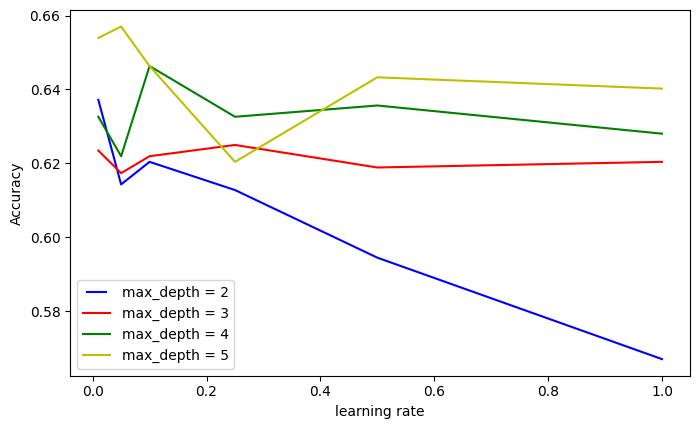

In [42]:
#Resultados_test[0:6] # max_depth = 1
#Resultados_test[6:12] # max_depth = 2
#Resultados_test[12:18] # max_depth = 3
#Resultados_test[18:24] # max_depth = 4

#Learning_rates
# pintamos los resultados de entrenamiento y validacion
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
plt.figure(figsize=(8, 4.75))
line1, = plt.plot(learning_rates, resultados_test[0:6], "b",
label = "max_depth = 2")
line2, = plt.plot(learning_rates, resultados_test[6:12], "r",
label = "max_depth = 3")
line2, = plt.plot(learning_rates, resultados_test[12:18], "g",
label = "max_depth = 4")
line2, = plt.plot(learning_rates, resultados_test[18:24], "y",
label = "max_depth = 5")
plt.legend(handler_map={line1: HandlerLine2D(numpoints = 4)})
plt.ylabel("Accuracy")
plt.xlabel("learning rate")
plt.show()

In [43]:
# crear objeto de la clase BaggingClassifier
gb_clf_b = GradientBoostingClassifier(n_estimators = 300,random_state = 2026, max_depth=5, learning_rate=0.01)

gb_clf_b.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [48]:
#Obtener el accuracy_score
y_pred_gb_b= gb_clf_b.predict(X_test)
accuracy_gb_b = accuracy_score(y_test, y_pred_gb_b)
print("El accuracy score que se tiene es %s" %accuracy_gb_b)

El accuracy score que se tiene es 0.6539634146341463


In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_gb_b = precision_score(y_test, y_pred_gb_b)
recall_gb_b = recall_score(y_test, y_pred_gb_b)
f1_gb_b = f1_score(y_test, y_pred_gb_b)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_gb_b, recall_gb_b,f1_gb_b]})
metricas

,Métricas,Valores
0,Precisión,0.708861
1,Recall,0.215385
2,F1,0.330383


Se entrenó un modelo de gradient boosting ajustado con learning_rate=0.01 y max_depth=5, obteniendo un accuracy score de 0.6554878048780488, lo que indica que clasificó correctamente aproximadamente el 65.55% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.717949, un recall de 0.215385 y un F1-score de 0.331361. Estos resultados muestran que el modelo mejora el accuracy respecto al gradient boosting anterior y también presenta una precisión más alta, por lo que sus predicciones positivas tienden a ser más confiables. Sin embargo, el recall disminuye, lo que significa que el modelo sigue dejando sin identificar una cantidad considerable de muestras de agua potable. En general, aunque este ajuste mejora el porcentaje global de clasificación correcta, no representa una mejora completa en el desempeño del modelo, ya que su capacidad para detectar correctamente los casos positivos continúa siendo limitada.

In [50]:
# Comparativa general

modelos = ["Arbol de decisión","Arbol de decisión b", "Bagging", "Pasting", "Random Forest", "Gradient Boosting", "Gradient Boosting ajustado"]
accuracy_scores = [accuracy_a,accuracy_b, accuracy_bag, accuracy_pas, accuracy_rf, accuracy_gb, accuracy_gb_b]
precision_scores = [precision_a, precision_b, precision_bag, precision_pas, precision_rf, precision_gb, precision_gb_b]
recall_scores = [recall_a, recall_b, recall_bag, recall_pas, recall_rf, recall_gb, recall_gb_b]
f1_scores = [f1_a, f1_b, f1_bag, f1_pas, f1_rf, f1_gb, f1_gb_b]

resultados = pd.DataFrame({"Modelos": modelos, "Accuracy": accuracy_scores, "Precisión": precision_scores, 
                           "Recall": recall_scores, "F1 Score": f1_scores})
resultados["Media"] = np.mean(resultados.drop("Modelos", axis=1), axis=1)

In [47]:
resultados

,Modelos,Accuracy,Precisión,Recall,F1 Score,Media
0,Arbol de decisión,0.634146,0.777778,0.107692,0.189189,0.427201
1,Arbol de decisión b,0.634146,0.565789,0.330769,0.417476,0.487045
2,Bagging,0.635671,0.677966,0.153846,0.250784,0.429567
3,Pasting,0.621951,0.596774,0.142308,0.229814,0.397712
4,Random Forest,0.638720,0.744681,0.134615,0.228013,0.436507
5,Gradient Boosting,0.635671,0.570470,0.326923,0.415648,0.487178
6,Gradient Boosting ajustado,0.653963,0.708861,0.215385,0.330383,0.477148


A partir de la comparación general de los modelos, se observa que el gradient boosting ajustado con learning_rate=0.01 y max_depth=5 obtuvo el mayor accuracy, con un valor de 0.6554878048780488, por lo que fue el modelo que clasificó correctamente una mayor proporción de muestras en términos globales. Sin embargo, su recall fue bajo, con un valor de 0.215385, lo que indica que no logró identificar una parte importante de las muestras realmente potables. Por otro lado, el árbol de decisión con max_depth=3 presentó el mejor equilibrio entre las métricas, ya que obtuvo una precisión de 0.728676, un recall de 0.678767 y un F1-score de 0.702837, siendo este último el valor más alto entre todos los modelos evaluados. Aunque random forest alcanzó una precisión alta de 0.787234 y un accuracy de 0.6448170731707317, su recall fue muy bajo, con 0.142308, lo que limita su capacidad para detectar correctamente las muestras potables. En general, aunque algunos modelos obtuvieron un accuracy ligeramente mayor, el árbol de decisión con max_depth=3 puede considerarse el modelo con mejor desempeño general, ya que mantiene un mejor balance entre precisión, recall y F1-score para la clasificación de la potabilidad del agua.